In [1]:
import tensorflow as tf
import numpy as np
import time
import gc
import os
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

✓ GPUs: 2
LOADING CIFAR-10
[✓] Loading from tf.keras.datasets (internet required)...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Full train : (50000, 32, 32, 3)
Full test  : (10000, 32, 32, 3)
Classes    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Subset — Train: (40000, 32, 32, 3) | Val: (5000, 32, 32, 3) | Test: (5000, 32, 32, 3)

NS-LSO: Multi-Objective CNN Optimization
Dataset: CIFAR-10

GENERATION 1/6


I0000 00:00:1780541587.347776      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780541587.354405      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780541596.140430     128 service.cc:152] XLA service 0x7f7798002fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780541596.140478     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780541596.140484     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780541596.896259     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780541609.769940     128 device_compiler.h:188] Compiled clust

  Lion  1/10: acc=0.8740 | inf=24.47ms | size=6.12MB
  Lion  2/10: acc=0.6802 | inf=50.92ms | size=46.02MB
  Lion  3/10: acc=0.5894 | inf=23.99ms | size=7.01MB
  Lion  4/10: acc=0.8974 | inf=32.81ms | size=40.77MB
  Lion  5/10: acc=0.8034 | inf=20.01ms | size=3.41MB
  Lion  6/10: acc=0.8074 | inf=20.18ms | size=1.71MB
  Lion  7/10: acc=0.8172 | inf=14.81ms | size=1.18MB
  Lion  8/10: acc=0.7096 | inf=43.46ms | size=33.56MB
  Lion  9/10: acc=0.7574 | inf=19.31ms | size=1.73MB
  Lion 10/10: acc=0.5746 | inf=21.07ms | size=4.49MB

  >>> FRONT-0: 3 solutions <<<
      acc=0.8740 | inf=24.47ms | size=6.12MB
      acc=0.8974 | inf=32.81ms | size=40.77MB
      acc=0.8172 | inf=14.81ms | size=1.18MB

GENERATION 2/6
  Lion  1/10: acc=0.8838 | inf=20.12ms | size=20.53MB
  Lion  2/10: acc=0.6174 | inf=33.95ms | size=41.91MB
  Lion  3/10: acc=0.5510 | inf=14.22ms | size=7.01MB
  Lion  4/10: acc=0.8948 | inf=31.89ms | size=41.28MB
  Lion  5/10: acc=0.8122 | inf=12.19ms | size=3.44MB
  Lion  6/10: a

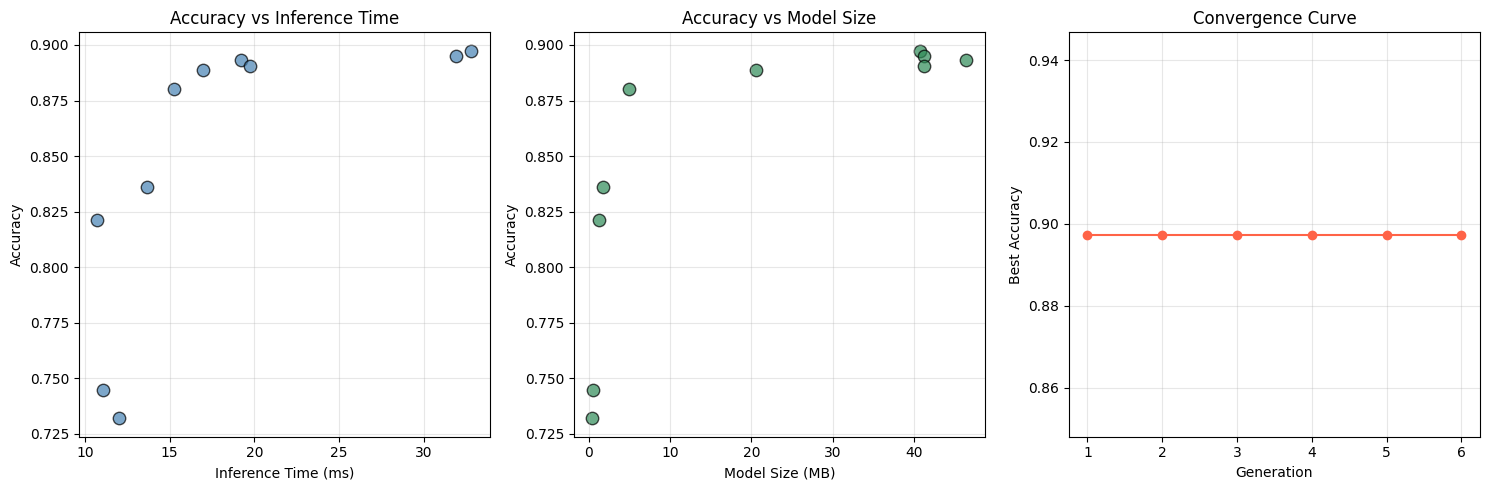

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPUs: {len(gpus)}")
else:
    print("⚠ No GPU - using CPU")

tf.keras.mixed_precision.set_global_policy('float32')


# ---------- 2. LOAD CIFAR-10 ----------
def load_cifar10_kaggle():
    possible_paths = [
        '/kaggle/input/cifar10',
        '/kaggle/input/cifar-10',
        '/kaggle/input/cifar-10-object-recognition',
        '/kaggle/input/cifar10-python',
    ]
    kaggle_path = next((p for p in possible_paths if os.path.exists(p)), None)

    if kaggle_path:
        print(f"[✓] Loading from Kaggle dataset: {kaggle_path}")

        def unpickle(file):
            with open(file, 'rb') as fo:
                return pickle.load(fo, encoding='bytes')

        def find_files(root, pattern):
            return sorted(
                os.path.join(dp, f)
                for dp, _, files in os.walk(root)
                for f in files if pattern in f
            )

        train_files = find_files(kaggle_path, 'data_batch')
        test_files  = find_files(kaggle_path, 'test_batch')
        meta_files  = find_files(kaggle_path, 'batches.meta')

        if not train_files or not test_files:
            print("⚠ Struktur tidak dikenali, fallback ke tf.keras...")
            kaggle_path = None

    if not kaggle_path:
        print("[✓] Loading from tf.keras.datasets (internet required)...")
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        class_names = ['airplane','automobile','bird','cat','deer',
                       'dog','frog','horse','ship','truck']
        y_train = y_train.flatten()
        y_test  = y_test.flatten()
    else:
        x_list, y_list = [], []
        for f in train_files:
            b = unpickle(f)
            x_list.append(b[b'data'])
            y_list.extend(b[b'labels'])
        x_train = np.concatenate(x_list).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        y_train = np.array(y_list, dtype='int32')

        tb = unpickle(test_files[0])
        x_test = tb[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        y_test = np.array(tb[b'labels'], dtype='int32')

        meta = unpickle(meta_files[0]) if meta_files else None
        class_names = ([n.decode() for n in meta[b'label_names']] if meta
                       else ['airplane','automobile','bird','cat','deer',
                             'dog','frog','horse','ship','truck'])

    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32')  / 255.0
    y_train = np.array(y_train, dtype='int32')
    y_test  = np.array(y_test,  dtype='int32')
    return (x_train, y_train), (x_test, y_test), class_names


print("=" * 60)
print("LOADING CIFAR-10")
print("=" * 60)
(x_train_full, y_train_full), (x_test_full, y_test_full), class_names = load_cifar10_kaggle()
print(f"Full train : {x_train_full.shape}")
print(f"Full test  : {x_test_full.shape}")
print(f"Classes    : {class_names}")


# ---------- 3. DATA SUBSET ----------
def prepare_subset(x_train, y_train, x_test, y_test,
                   train_size=40000, val_size=5000, test_size=5000, seed=42):
    rng = np.random.default_rng(seed)

    train_idx = rng.choice(len(x_train), min(train_size, len(x_train)), replace=False)
    x_tr, y_tr = x_train[train_idx], y_train[train_idx]

    available = len(x_test)
    val_size  = min(val_size,  available // 2)
    test_size = min(test_size, available - val_size)

    perm = rng.permutation(available)
    x_val = x_test[perm[:val_size]]
    y_val = y_test[perm[:val_size]]
    x_te  = x_test[perm[val_size:val_size + test_size]]
    y_te  = y_test[perm[val_size:val_size + test_size]]

    return (x_tr, y_tr), (x_val, y_val), (x_te, y_te)


(x_train, y_train), (x_val, y_val), (x_test, y_test) = prepare_subset(
    x_train_full, y_train_full, x_test_full, y_test_full
)
print(f"\nSubset — Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")


# ---------- 4. AUGMENTATION PIPELINE (tf.data — di luar model) ----------
# FIX: Augmentasi dipindah ke tf.data pipeline agar tidak konflik dengan
#      GPU layout optimizer (penyebab error NHWC→NCHW).

@tf.function
def augment(image, label):
    """Augmentasi ringan yang stabil di semua versi TF."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    # Padding + random crop = simulasi random translation
    image = tf.pad(image, [[4, 4], [4, 4], [0, 0]], mode='REFLECT')
    image = tf.image.random_crop(image, size=[32, 32, 3])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def make_dataset(x, y, batch_size, augment_data=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x), seed=42)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# ---------- 5. CLASS LION ----------
class Lion:
    def __init__(self, hyperparameters: dict):
        self.hyperparameters = hyperparameters.copy()

    def __repr__(self):
        hp = self.hyperparameters
        return (f"Lion(lr={hp.get('learning_rate', 0):.5f}, "
                f"layers={hp.get('num_layers', 0)}, "
                f"filters={hp.get('filters_base', 0)}, "
                f"batch={hp.get('batch_size', 0)})")


# ---------- 6. CNN BUILDER (tanpa augmentasi dalam model) ----------
def build_cnn_model(hp: dict):
    """
    FIX: Augmentasi dihapus dari dalam model — dipindah ke tf.data pipeline.
    Ini menghilangkan error layout NHWC→NCHW pada GPU Kaggle.
    """
    num_layers   = int(np.clip(hp['num_layers'],   2, 5))
    filters_base = int(np.clip(hp['filters_base'], 32, 256))
    dropout_rate = float(np.clip(hp['dropout_rate'], 0.1, 0.5))
    dense_units  = int(np.clip(hp['dense_units'],  64, 512))

    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = inputs

    for i in range(num_layers):
        filters = min(filters_base * (2 ** i), 512)

        # Conv block 1
        x = tf.keras.layers.Conv2D(
            filters, 3, padding='same', use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)

        # Conv block 2 (VGG-style double conv)
        x = tf.keras.layers.Conv2D(
            filters, 3, padding='same', use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)

        x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(
        dense_units, use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


# ---------- 7. MULTI-OBJECTIVE FITNESS ----------
def evaluate_multi(lion: Lion, x_train, y_train, x_val, y_val,
                   epochs: int = 15, verbose: int = 0) -> dict:
    hp = lion.hyperparameters
    batch_size = int(np.clip(hp['batch_size'], 32, 256))

    model = build_cnn_model(hp)

    # FIX: Gunakan float LR biasa (bukan LearningRateSchedule)
    #      agar tidak konflik dengan callback apapun di masa depan.
    #      Cosine decay diimplementasi manual via callback.
    initial_lr = float(hp['learning_rate'])

    optimizer = tf.keras.optimizers.Adam(learning_rate=initial_lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    steps_per_epoch = max(1, len(x_train) // batch_size)
    total_steps     = steps_per_epoch * epochs

    # FIX: CosineDecay diimplementasi sebagai LambdaCallback
    #      — tidak konflik karena set lewat assign(), bukan schedule object
    def cosine_lr(step, total, lr_start, lr_min=1e-6):
        cos_val = 0.5 * (1 + np.cos(np.pi * step / total))
        return lr_min + (lr_start - lr_min) * cos_val

    class CosineDecayCallback(tf.keras.callbacks.Callback):
        def __init__(self, lr_start, total_steps):
            super().__init__()
            self.lr_start    = lr_start
            self.total_steps = total_steps
            self.step        = 0

        def on_train_batch_end(self, batch, logs=None):
            self.step += 1
            new_lr = cosine_lr(self.step, self.total_steps, self.lr_start)
            self.model.optimizer.learning_rate.assign(new_lr)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=0
        ),
        CosineDecayCallback(lr_start=initial_lr, total_steps=total_steps)
    ]

    # Buat tf.data dataset dengan augmentasi
    train_ds = make_dataset(x_train, y_train, batch_size, augment_data=True)
    val_ds   = make_dataset(x_val,   y_val,   batch_size, augment_data=False, shuffle=False)

    try:
        t0 = time.time()
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=callbacks,
            verbose=verbose
        )
        train_time = time.time() - t0
        val_acc = max(history.history['val_accuracy'])
    except Exception as e:
        print(f"    ⚠ Training error: {e}")
        del model; gc.collect(); tf.keras.backend.clear_session()
        return {'accuracy': 0.0, 'inference_time': 999.0,
                'model_size': 999.0, 'train_time': 0.0}

    # Inference time
    val_sample = x_val[:100]
    t1 = time.time()
    model.predict(val_sample, verbose=0)
    inf_time = (time.time() - t1) / 100 * 1000

    model_size = model.count_params() * 4 / (1024 ** 2)

    del model; gc.collect(); tf.keras.backend.clear_session()
    return {
        'accuracy':       float(val_acc),
        'inference_time': float(inf_time),
        'model_size':     float(model_size),
        'train_time':     float(train_time)
    }


# ---------- 8. NORMALISASI & DOMINANCE ----------
def normalize_objectives(pop_fit: list) -> list:
    if not pop_fit:
        return pop_fit
    keys   = ['accuracy', 'inference_time', 'model_size']
    minmax = {k: (min(p[k] for p in pop_fit), max(p[k] for p in pop_fit)) for k in keys}
    for p in pop_fit:
        for k in keys:
            mn, mx = minmax[k]
            p[k + '_norm'] = (p[k] - mn) / (mx - mn) if mx != mn else 0.5
    return pop_fit


def dominates(a: dict, b: dict) -> bool:
    a_vals = (-a['accuracy_norm'], a['inference_time_norm'], a['model_size_norm'])
    b_vals = (-b['accuracy_norm'], b['inference_time_norm'], b['model_size_norm'])
    return (all(av <= bv for av, bv in zip(a_vals, b_vals)) and
            any(av <  bv for av, bv in zip(a_vals, b_vals)))


# ---------- 9. NSGA-II ----------
def fast_non_dominated_sort(pop: list) -> list:
    if not pop:
        return []
    n = len(pop)
    dom_count = [0] * n
    dom_list  = [[] for _ in range(n)]
    fronts    = [[]]

    for i in range(n):
        for j in range(n):
            if i == j: continue
            if dominates(pop[i], pop[j]):
                dom_list[i].append(j)
            elif dominates(pop[j], pop[i]):
                dom_count[i] += 1
        if dom_count[i] == 0:
            fronts[0].append(i)

    i = 0
    while i < len(fronts) and fronts[i]:
        nf = []
        for idx in fronts[i]:
            for j in dom_list[idx]:
                dom_count[j] -= 1
                if dom_count[j] == 0:
                    nf.append(j)
        if nf:
            fronts.append(nf)
        i += 1

    return [[pop[idx] for idx in f] for f in fronts if f]


def crowding_distance(front: list) -> list:
    n = len(front)
    if n <= 2:
        return [float('inf')] * n
    dists = [0.0] * n
    for obj in ['accuracy_norm', 'inference_time_norm', 'model_size_norm']:
        sidx = sorted(range(n), key=lambda x: front[x][obj])
        dists[sidx[0]] = dists[sidx[-1]] = float('inf')
        span = front[sidx[-1]][obj] - front[sidx[0]][obj]
        if span == 0:
            continue
        for k in range(1, n - 1):
            dists[sidx[k]] += (front[sidx[k+1]][obj] - front[sidx[k-1]][obj]) / span
    return dists


# ---------- 10. LION UPDATE ----------
def lion_update(lion: Lion, front_0: list, beta=0.9, eta=0.1) -> Lion:
    hp = lion.hyperparameters.copy()

    mean_acc = np.mean([p['accuracy'] for p in front_0]) if front_0 else 0.5
    grad     = (hp.get('last_acc', 0.5) - mean_acc) / (mean_acc + 1e-8)

    mom = beta * hp.get('momentum_lr', 0.0) + (1 - beta) * grad
    hp['momentum_lr'] = float(mom)
    hp['learning_rate'] = float(np.clip(
        hp['learning_rate'] * (1 + eta * np.sign(mom + 1e-8)), 1e-5, 1e-2
    ))

    if np.random.rand() < 0.3:
        hp['num_layers'] = int(np.clip(
            hp['num_layers'] + np.random.choice([-1, 1]), 2, 5
        ))

    for param in ['filters_base', 'dense_units']:
        if np.random.rand() < 0.3:
            hp[param] = int(max(32, hp[param] * np.random.uniform(0.85, 1.15)))

    if np.random.rand() < 0.3:
        choices = [32, 64, 128, 256]
        idx = min(range(len(choices)), key=lambda x: abs(choices[x] - int(hp['batch_size'])))
        hp['batch_size'] = choices[int(np.clip(
            idx + np.random.choice([-1, 1]), 0, len(choices) - 1
        ))]

    if np.random.rand() < 0.3:
        hp['dropout_rate'] = float(np.clip(
            hp['dropout_rate'] + np.random.normal(0, 0.05), 0.1, 0.5
        ))

    return Lion(hp)


# ---------- 11. OPTIMIZER ----------
class NSLSO_Optimizer:
    def __init__(self, population_size=10, max_generations=6, hp_range=None):
        self.pop_size = population_size
        self.max_gen  = max_generations
        self.hp_range = hp_range or {
            'learning_rate': (1e-4, 5e-3),
            'batch_size':    (32, 256),
            'num_layers':    (2, 5),
            'filters_base':  (32, 128),
            'dropout_rate':  (0.1, 0.5),
            'dense_units':   (64, 512)
        }
        self.swarm   = []
        self.archive = []
        self.history = []

    def initialize(self):
        rng = np.random.default_rng(42)
        self.swarm = []
        for _ in range(self.pop_size):
            hp = {}
            for param, (low, high) in self.hp_range.items():
                if param == 'learning_rate':
                    hp[param] = float(10 ** rng.uniform(np.log10(low), np.log10(high)))
                elif param in ['num_layers', 'batch_size', 'filters_base', 'dense_units']:
                    hp[param] = int(rng.integers(low, high + 1))
                else:
                    hp[param] = float(rng.uniform(low, high))
            hp['momentum_lr'] = 0.0
            hp['last_acc']    = 0.0
            self.swarm.append(Lion(hp))

    def optimize(self, x_train, y_train, x_val, y_val,
                 epochs_per_eval=15, verbose=1):
        self.initialize()

        for gen in range(1, self.max_gen + 1):
            if verbose:
                print(f"\n{'='*60}")
                print(f"GENERATION {gen}/{self.max_gen}")
                print(f"{'='*60}")

            pop_fit = []
            for i, lion in enumerate(self.swarm):
                fit = evaluate_multi(lion, x_train, y_train, x_val, y_val,
                                     epochs=epochs_per_eval, verbose=0)
                lion.hyperparameters['last_acc'] = fit['accuracy']

                if fit['accuracy'] < 0.15:
                    if verbose:
                        print(f"  Lion {i+1:2d}: FAILED (acc={fit['accuracy']:.4f})")
                    continue

                fit['hyperparams'] = {
                    k: v for k, v in lion.hyperparameters.items()
                    if not k.startswith('momentum') and k != 'last_acc'
                }
                pop_fit.append(fit)

                if verbose:
                    print(f"  Lion {i+1:2d}/{self.pop_size}: "
                          f"acc={fit['accuracy']:.4f} | "
                          f"inf={fit['inference_time']:.2f}ms | "
                          f"size={fit['model_size']:.2f}MB")

            if not pop_fit:
                print("  ⚠ All failed! Using backup...")
                fit = evaluate_multi(self.swarm[0], x_train, y_train,
                                     x_val, y_val, epochs=5)
                fit['hyperparams'] = {
                    k: v for k, v in self.swarm[0].hyperparameters.items()
                    if not k.startswith('momentum') and k != 'last_acc'
                }
                fit['accuracy'] = max(fit['accuracy'], 0.15)
                pop_fit.append(fit)

            pop_fit  = normalize_objectives(pop_fit)
            combined = normalize_objectives(pop_fit + self.archive)
            fronts   = fast_non_dominated_sort(combined)

            new_archive = []
            for front in fronts:
                if len(new_archive) + len(front) <= self.pop_size:
                    new_archive.extend(front)
                else:
                    cd     = crowding_distance(front)
                    ranked = sorted(zip(cd, front), key=lambda x: x[0], reverse=True)
                    rem    = self.pop_size - len(new_archive)
                    new_archive.extend(s for _, s in ranked[:rem])
                    break
            self.archive = new_archive

            front_0 = fronts[0] if fronts else []
            if front_0:
                print(f"\n  >>> FRONT-0: {len(front_0)} solutions <<<")
                for sol in front_0[:3]:
                    print(f"      acc={sol['accuracy']:.4f} | "
                          f"inf={sol['inference_time']:.2f}ms | "
                          f"size={sol['model_size']:.2f}MB")
            else:
                print("  >>> FRONT-0: EMPTY <<<")

            self.swarm = [lion_update(lion, front_0) for lion in self.swarm]
            self.history.append({
                'generation':   gen,
                'front_0_size': len(front_0),
                'archive_size': len(self.archive),
                'best_acc':     max((s['accuracy'] for s in self.archive), default=0.0)
            })

            if gen % 2 == 0:
                self._save_checkpoint(f'/kaggle/working/nslso_checkpoint_gen{gen}.json')

        return self.archive

    def _save_checkpoint(self, path):
        def _cast(v):
            if isinstance(v, (np.floating, float)): return float(v)
            if isinstance(v, (np.integer, int)):     return int(v)
            if isinstance(v, np.ndarray):            return v.tolist()
            return v
        with open(path, 'w') as f:
            json.dump({
                'archive': [{k: _cast(v) for k, v in s.items() if k != 'hyperparams'}
                            for s in self.archive],
                'history': self.history
            }, f, indent=2)
        print(f"  [✓] Checkpoint saved: {path}")


# ---------- 12. MAIN ----------
def main():
    print("\n" + "=" * 60)
    print("NS-LSO: Multi-Objective CNN Optimization")
    print("Dataset: CIFAR-10")
    print("=" * 60)

    nslso = NSLSO_Optimizer(
        population_size=10,
        max_generations=6,
        hp_range={
            'learning_rate': (1e-4, 5e-3),
            'batch_size':    (32, 256),
            'num_layers':    (2, 5),
            'filters_base':  (32, 128),
            'dropout_rate':  (0.1, 0.5),
            'dense_units':   (64, 256)
        }
    )

    start = time.time()
    pareto_front = nslso.optimize(
        x_train, y_train, x_val, y_val,
        epochs_per_eval=15,
        verbose=1
    )
    total_time = time.time() - start

    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    print(f"Total time   : {total_time/3600:.2f} hours")
    print(f"Pareto-front : {len(pareto_front)} solutions")

    pareto_front.sort(key=lambda x: x['accuracy'], reverse=True)
    print("\n--- TOP 5 PARETO SOLUTIONS ---")
    for i, sol in enumerate(pareto_front[:5], 1):
        hp = sol['hyperparams']
        print(f"\n  Solution {i}:")
        print(f"    Accuracy   : {sol['accuracy']:.4f}")
        print(f"    Inference  : {sol['inference_time']:.2f} ms")
        print(f"    Model size : {sol['model_size']:.2f} MB")
        print(f"    Config     : lr={hp['learning_rate']:.5f}, "
              f"layers={hp['num_layers']}, filters={hp['filters_base']}, "
              f"batch={hp['batch_size']}, dense={hp['dense_units']}, "
              f"dropout={hp['dropout_rate']:.2f}")

    # Evaluasi final di test set dengan lebih banyak epoch
    print("\n[5] Final evaluation on test set (30 epochs)...")
    best_lion   = Lion(pareto_front[0]['hyperparams'])
    test_result = evaluate_multi(best_lion, x_train, y_train, x_test, y_test,
                                 epochs=30, verbose=1)
    print(f"\n  Best model test accuracy : {test_result['accuracy']:.4f}")
    print(f"  Inference time           : {test_result['inference_time']:.2f} ms")
    print(f"  Model size               : {test_result['model_size']:.2f} MB")

    def _cast(v):
        if isinstance(v, (np.floating, float)): return float(v)
        if isinstance(v, (np.integer, int)):     return int(v)
        if isinstance(v, np.ndarray):            return v.tolist()
        return v

    with open('/kaggle/working/nslso_final_results.json', 'w') as f:
        json.dump({
            'pareto_front':     [{k: _cast(v) for k, v in s.items() if k != 'hyperparams'}
                                 for s in pareto_front],
            'hyperparams':      [s['hyperparams'] for s in pareto_front],
            'total_time_hours': total_time / 3600,
            'class_names':      class_names,
            'test_accuracy':    float(test_result['accuracy'])
        }, f, indent=2)
    print("[✓] Results saved to /kaggle/working/nslso_final_results.json")

    # Visualisasi
    try:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        accs  = [s['accuracy']       for s in pareto_front]
        infs  = [s['inference_time'] for s in pareto_front]
        sizes = [s['model_size']     for s in pareto_front]

        axes[0].scatter(infs, accs, s=80, alpha=0.7, c='steelblue', edgecolors='k')
        axes[0].set(xlabel='Inference Time (ms)', ylabel='Accuracy',
                    title='Accuracy vs Inference Time')
        axes[0].grid(alpha=0.3)

        axes[1].scatter(sizes, accs, s=80, alpha=0.7, c='seagreen', edgecolors='k')
        axes[1].set(xlabel='Model Size (MB)', ylabel='Accuracy',
                    title='Accuracy vs Model Size')
        axes[1].grid(alpha=0.3)

        axes[2].plot([h['generation'] for h in nslso.history],
                     [h['best_acc']   for h in nslso.history],
                     marker='o', color='tomato')
        axes[2].set(xlabel='Generation', ylabel='Best Accuracy',
                    title='Convergence Curve')
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig('/kaggle/working/pareto_front.png', dpi=150, bbox_inches='tight')
        print("[✓] Plot saved to /kaggle/working/pareto_front.png")
        plt.show()
    except Exception as e:
        print(f"Plotting skipped: {e}")

    return pareto_front


if __name__ == "__main__":
    pareto = main()